# 1. Import Libraries

In [112]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Activation, Dense, Flatten, Input, Conv2D, MaxPool2D
)
from tensorflow.keras.utils import plot_model
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from IPython.display import Image
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [113]:
base_dir = r'/content/drive/MyDrive/Colab Notebooks/flower_images'
folders = os.listdir(base_dir)

In [114]:
val_split=0.3

train_gen=ImageDataGenerator(rescale=1./255, validation_split=val_split)

train_generator=train_gen.flow_from_directory(
    base_dir,
    target_size=(128,128),
    batch_size=64,
    class_mode='sparse',
    subset='training')

validation_generator=train_gen.flow_from_directory(
    base_dir,
    target_size=(128,128),
    batch_size=64,
    class_mode='sparse',
    subset='validation')

Found 3500 images belonging to 5 classes.
Found 1500 images belonging to 5 classes.


In [ ]:
"""#바꾼 이미지데이터제너레이터

val_split=0.3

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=val_split
)

train_generator=train_gen.flow_from_directory(
    base_dir,
    target_size=(128,128),
    batch_size=64,
    class_mode='sparse',
    subset='training')

validation_generator=train_gen.flow_from_directory(
    base_dir,
    target_size=(128,128),
    batch_size=64,
    class_mode='sparse',
    subset='validation')"""

Found 3500 images belonging to 5 classes.
Found 1500 images belonging to 5 classes.


In [115]:
x_train,y_train=train_generator.next()
x_valid,y_valid=validation_generator.next()
print(y_train,y_valid)

[4. 3. 2. 1. 4. 1. 2. 4. 0. 1. 4. 1. 0. 1. 4. 0. 0. 3. 1. 0. 3. 4. 2. 3.
 3. 2. 2. 3. 2. 0. 2. 1. 4. 0. 0. 3. 0. 1. 3. 1. 3. 1. 4. 4. 0. 3. 0. 1.
 0. 4. 2. 1. 4. 4. 1. 3. 2. 3. 4. 4. 2. 2. 1. 1.] [3. 3. 0. 1. 2. 2. 4. 2. 0. 1. 2. 3. 4. 3. 2. 2. 2. 4. 2. 1. 2. 0. 1. 4.
 0. 4. 0. 3. 1. 3. 1. 0. 3. 3. 2. 1. 3. 0. 1. 0. 4. 1. 0. 3. 4. 4. 2. 4.
 1. 3. 2. 3. 3. 4. 4. 2. 4. 1. 2. 3. 2. 0. 4. 2.]


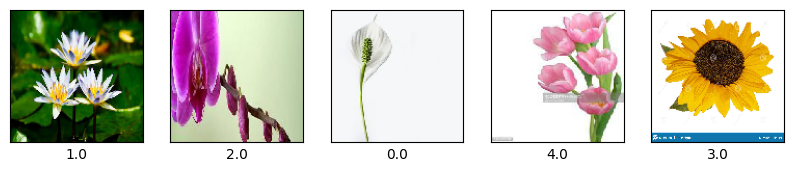

In [107]:
plt.figure(figsize=(10,10))
for i in range(5):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])
plt.show()


In [ ]:
#print(train_gen.class_names)

In [116]:
#image

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')])

In [117]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_34 (Conv2D)          (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d_34 (MaxPoolin  (None, 63, 63, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_35 (Conv2D)          (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_35 (MaxPoolin  (None, 30, 30, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_36 (Conv2D)          (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_36 (MaxPoolin  (None, 14, 14, 128)    

In [118]:
early_stopping = EarlyStopping(monitor = 'val_accuracy', min_delta = 0, patience = 1, mode = 'auto')

In [119]:
history = model.fit(train_generator,
                    epochs=20,
                    validation_data=validation_generator,
                    callbacks = [early_stopping])

Epoch 1/20
55/55 [==============================] - 40s 702ms/step - loss: 1.3525 - accuracy: 0.4269 - val_loss: 1.1643 - val_accuracy: 0.5013
Epoch 2/20
55/55 [==============================] - 38s 694ms/step - loss: 1.0279 - accuracy: 0.5934 - val_loss: 1.0179 - val_accuracy: 0.5907
Epoch 3/20
55/55 [==============================] - 38s 686ms/step - loss: 0.8307 - accuracy: 0.6851 - val_loss: 0.8507 - val_accuracy: 0.6780
Epoch 4/20
55/55 [==============================] - 38s 694ms/step - loss: 0.5925 - accuracy: 0.7783 - val_loss: 0.7530 - val_accuracy: 0.7220
Epoch 5/20
55/55 [==============================] - 39s 709ms/step - loss: 0.4076 - accuracy: 0.8577 - val_loss: 0.7713 - val_accuracy: 0.7420
Epoch 6/20
55/55 [==============================] - 38s 687ms/step - loss: 0.2679 - accuracy: 0.9046 - val_loss: 0.7280 - val_accuracy: 0.7913
Epoch 7/20
55/55 [==============================] - 38s 689ms/step - loss: 0.1588 - accuracy: 0.9503 - val_loss: 0.8199 - val_accuracy: 0.7840

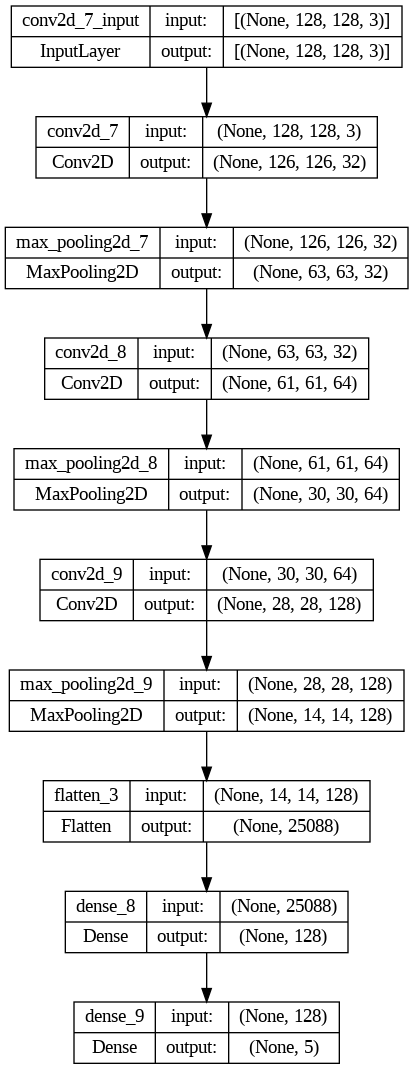

In [ ]:
plot_model(model, show_shapes=True)

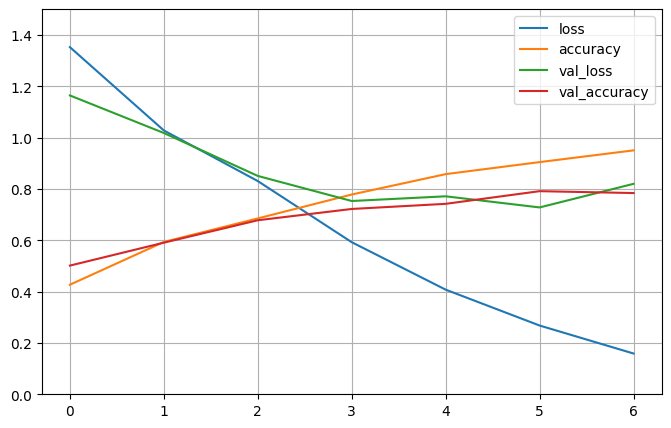

In [120]:
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1.5)
plt.show()

# 학습된 모델에 Test data 입력해서 결과 확인

In [121]:
test_dir = r'/content/drive/MyDrive/Colab Notebooks/test_flower'

testset_generator=train_gen.flow_from_directory(
    test_dir,
    target_size=(128,128),
    class_mode='sparse')

Found 25 images belonging to 5 classes.


In [122]:
x_test,y_test=testset_generator.next()

In [123]:
testclass_name=dict((a,b) for b,a in train_generator.class_indices.items())
testclass_name

{0: 'Lilly', 1: 'Lotus', 2: 'Orchid', 3: 'Sunflower', 4: 'Tulip'}

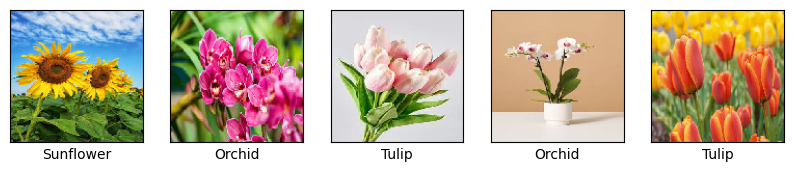

In [124]:
plt.figure(figsize=(10,10))
for i in range(5):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[i], cmap=plt.cm.binary)
    plt.xlabel(testclass_name[y_test[i]])
plt.show()

In [125]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print('\nTest accuracy:', test_acc)

1/1 - 0s - loss: 0.6893 - accuracy: 0.8000 - 27ms/epoch - 27ms/step

Test accuracy: 0.800000011920929


In [126]:
probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])
predictions = probability_model.predict(x_test)

1/1 [==============================] - 0s 73ms/step


In [127]:
def plot_image(i, predictions_array, true_label, img):
  true_label, img = true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(testclass_name[predicted_label],
                                100*np.max(predictions_array),
                                testclass_name[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  true_label = true_label[i]
  true_label=int(true_label)
  plt.grid(False)
  plt.xticks(range(5))
  plt.yticks([])
  thisplot = plt.bar(range(5), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

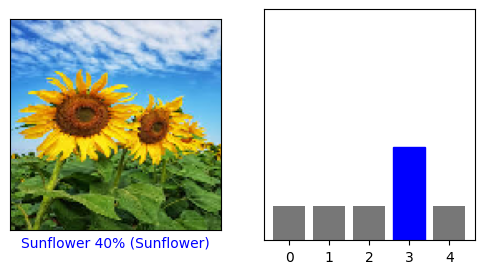

In [132]:
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], y_test, x_test)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i], y_test)
plt.show()

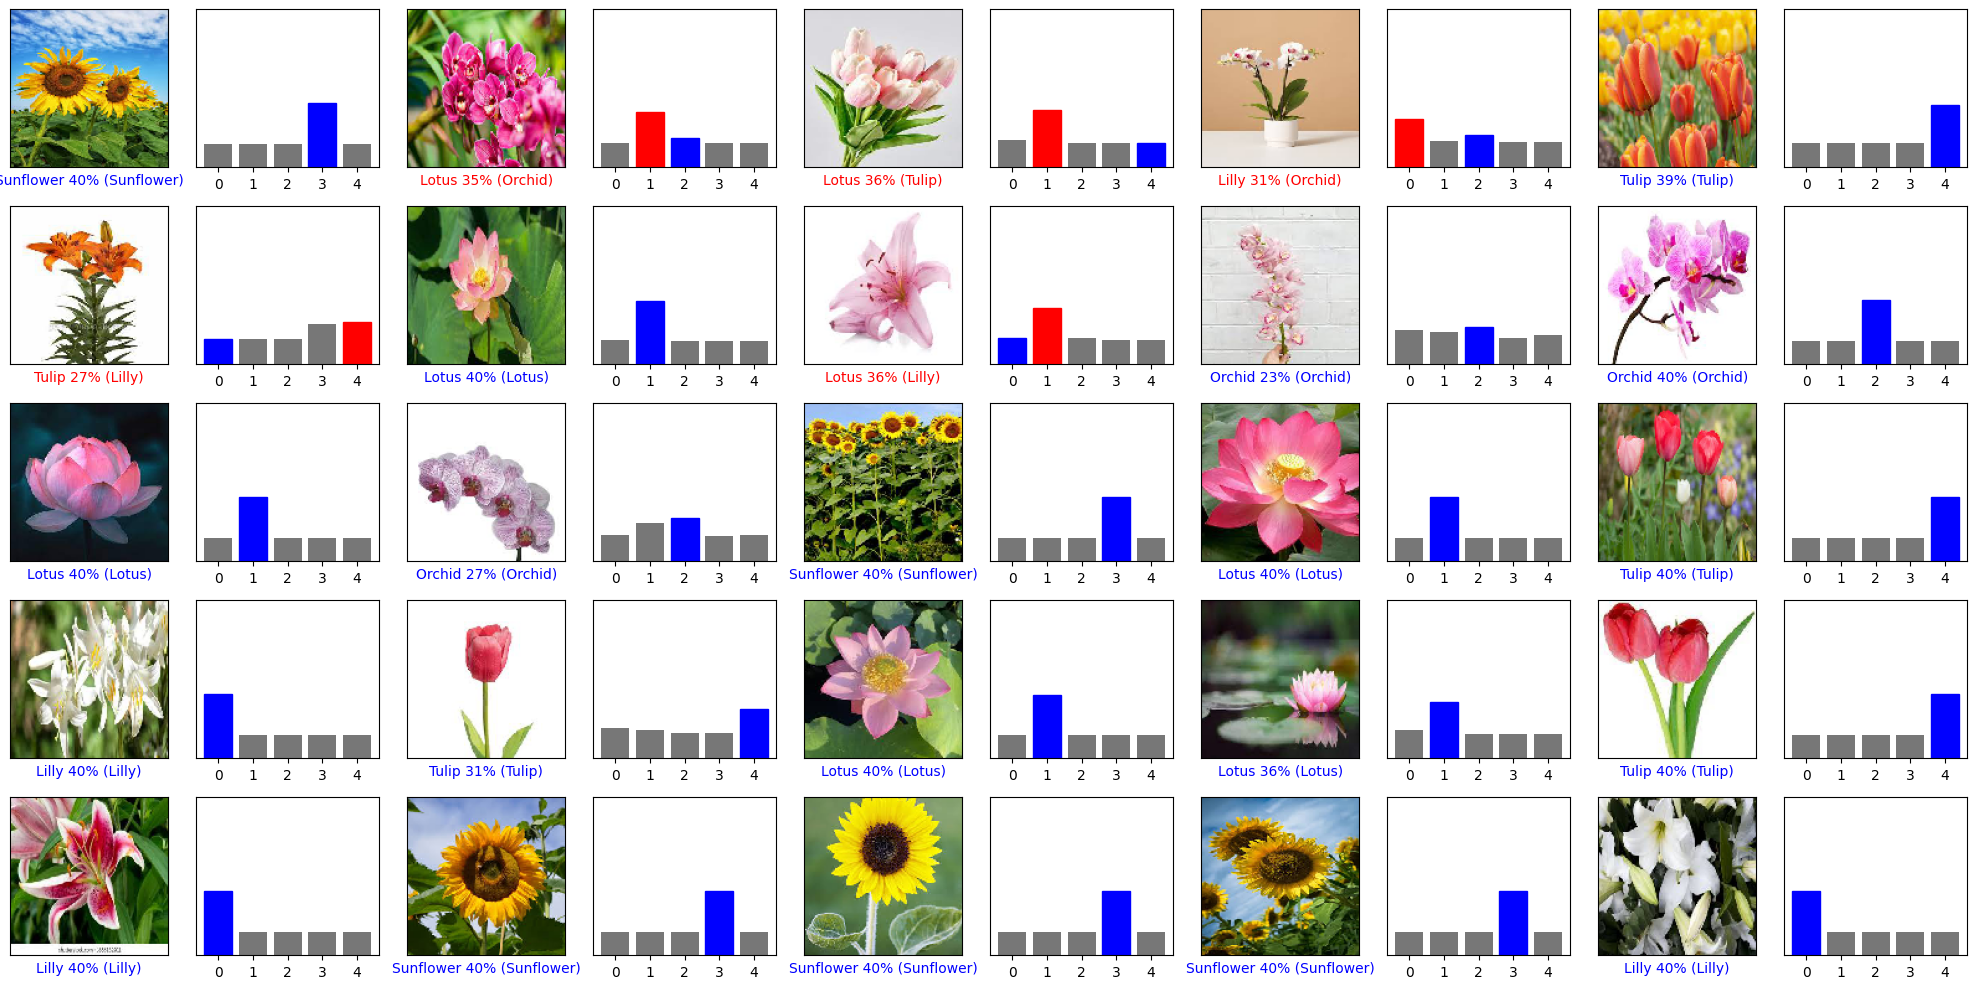

In [129]:
num_rows = 5
num_cols = 5
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions[i], y_test, x_test)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions[i], y_test)
plt.tight_layout()
plt.show()